<a href="https://colab.research.google.com/github/sebaspatric/curso-estadistica-multivariante/blob/main/Seccion%201%20Introducci%C3%B3n%20al%20espacio%20multivariante/C%C3%B3digos/Python/1.C%20Iris_Dataset_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vamos a ver un ejemplo de análisis descriptivo con el dataset IRIS

Importamos las librerías que vamos a utilizar

In [23]:
import numpy as np
import scipy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.datasets import load_iris
from math import pi
from pandas.plotting import scatter_matrix
from pandas.plotting import andrews_curves


Subimos el dataset donde lo tengamos, en nuestro caso lo tenemos en Drive o Local.
Pasos para subir desde un directorio local:


1.   En el menú de la izquierda click en Archivos.
2.   Click en Subir.
3.   Buscar el archivo y seleccionarlo.



In [24]:
link1 ="https://github.com/sebaspatric/curso-estadistica-multivariante/blob/main/"

In [25]:
link2= "Seccion 1 Introducción al espacio multivariante/Datos/Iris.csv"

In [26]:
import urllib.parse

# Transform link1 to its raw content base URL
raw_base_url = link1.replace('github.com', 'raw.githubusercontent.com').replace('/blob/', '/')

# URL-encode link2 to handle spaces and special characters correctly
encoded_link2 = urllib.parse.quote(link2)

# Combine the raw base URL with the encoded file path
full_raw_link = raw_base_url + encoded_link2

print(f"The combined raw link is: {full_raw_link}")


The combined raw link is: https://raw.githubusercontent.com/sebaspatric/curso-estadistica-multivariante/main/Seccion%201%20Introducci%C3%B3n%20al%20espacio%20multivariante/Datos/Iris.csv


In [27]:
iris = pd.read_csv(full_raw_link)

In [ ]:
#iris=pd.read_csv('./Iris.csv')
#iris es ahora un objeto DataFrame de Pandas

Ahora vamos a hacernos las primeras preguntas:


1.   ¿Cuántos datos hay en el dataset?
2.   ¿Cuántas variables?
3.   ¿Cuántos grupos de variables o categorías?
4.   ¿Cuántas observaciones corresponden a cada grupo?

In [28]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [29]:
print(iris.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [30]:
iris.shape

(150, 6)

In [31]:
iris['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


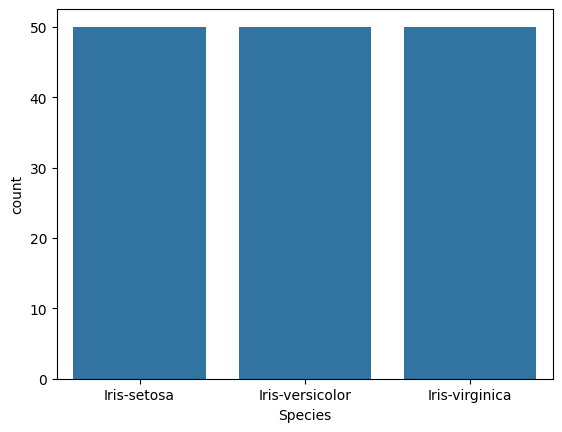

In [33]:
sns.countplot(x='Species', data=iris)
plt.show()

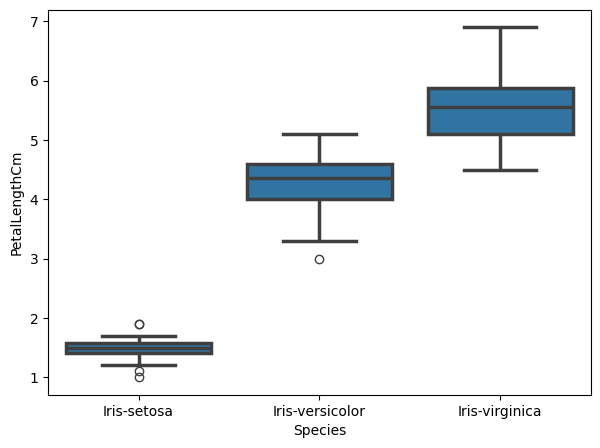

In [35]:
# Boxplots
fig = plt.gcf()
fig.set_size_inches(7, 5)
sns.boxplot(x="Species", y="PetalLengthCm", data=iris  ,linewidth=2.5 )
plt.show()

Vamos a quitar la variable Id que no nos interesa.

In [38]:
iris_num=iris.drop("Id", axis=1)

In [39]:
iris_num.shape

(150, 5)

In [40]:
iris_num.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [41]:
iris_num['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


¿Qué medidas numéricas podemos obtener para describir los datos?

In [42]:
iris_num.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Gráficamente, ¿cómo podemos ver la cantidad de observaciones en cada grupo?

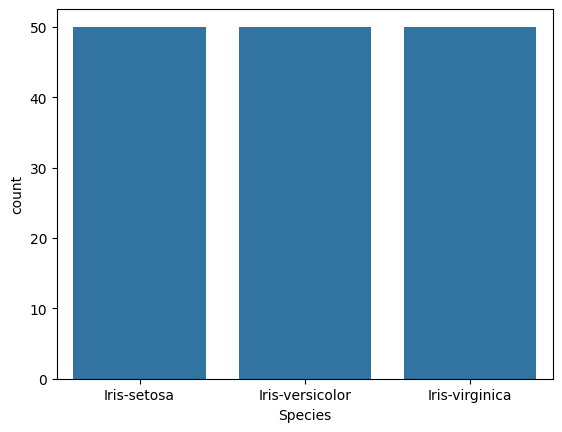

In [44]:
sns.countplot(x='Species',data=iris)
plt.show()

Veamos cómo hacer boxplots por grupos

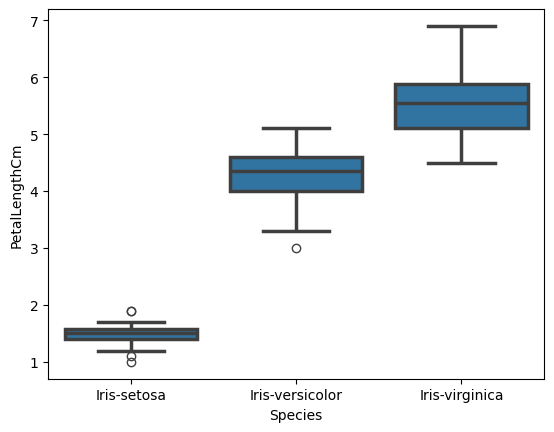

In [45]:
# Boxplots
sns.boxplot(x="Species", y="PetalLengthCm", data=iris  ,linewidth=2.5 )
plt.show()

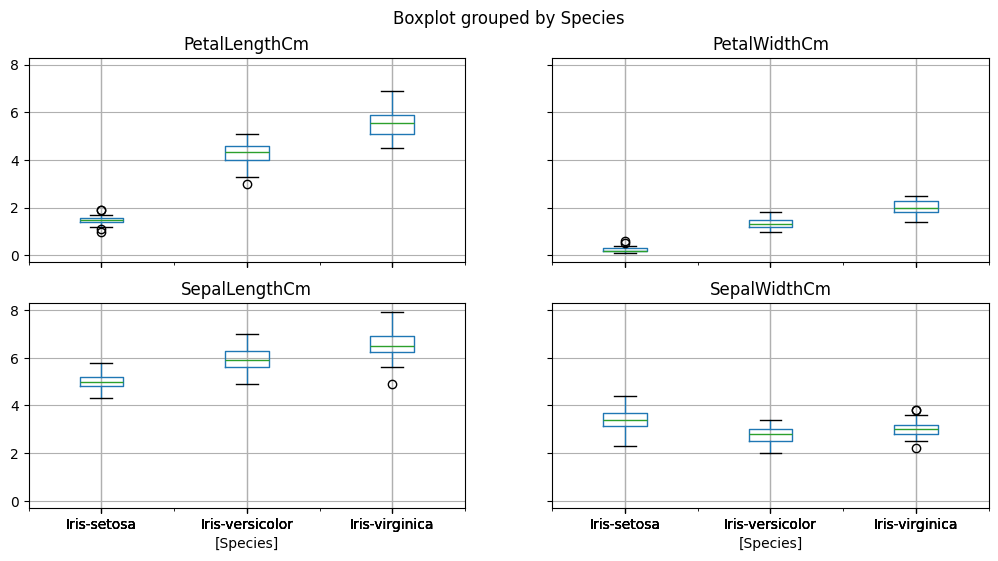

In [46]:
# Boxplots para cada variable divididos por grupos en "Species"
iris_num.boxplot(by="Species", figsize=(12, 6))
plt.show() #esto último se pone cuando no se quiere que salga el último mensaje informativo

Veamos cómo hacer histogramas por grupos

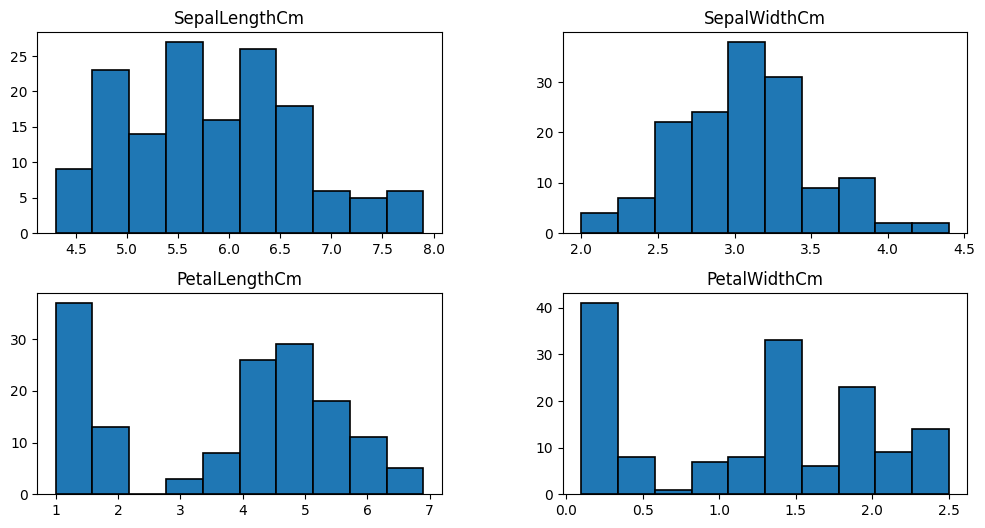

In [47]:
# Histogramas
iris_num.hist(edgecolor='black', linewidth=1.2, grid=False, figsize=(12, 6))
plt.show()

# Otra forma de obtener los datos Iris es usar `sklearn`

In [48]:
# Histogramas divididos por subgrupos
# Otra forma de importar los datos de iris
from sklearn.datasets import load_iris
irissk = load_iris()

#irissk es ahora un numpy array
X = irissk.data
Y = irissk.target


In [49]:
X.shape

(150, 4)

Con scipy(sc).stats podemos obtener medidas numéricas que describen las variables

In [50]:
sc.stats.describe(X)

DescribeResult(nobs=np.int64(150), minmax=(array([4.3, 2. , 1. , 0.1]), array([7.9, 4.4, 6.9, 2.5])), mean=array([5.84333333, 3.05733333, 3.758     , 1.19933333]), variance=array([0.68569351, 0.18997942, 3.11627785, 0.58100626]), skewness=array([ 0.31175306,  0.31576711, -0.27212767, -0.10193421]), kurtosis=array([-0.57356795,  0.18097632, -1.39553589, -1.33606741]))

Histogramas por grupos

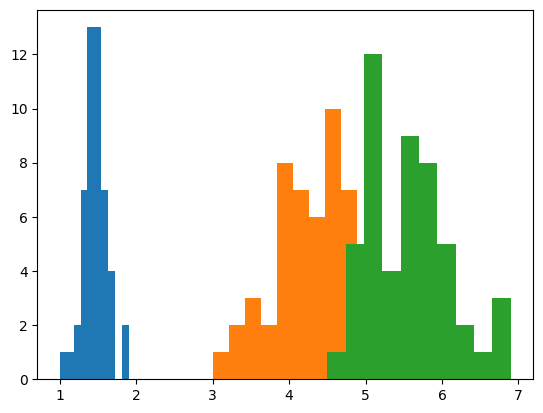

In [51]:
plt.hist(X[Y == 0,2])
plt.hist(X[Y == 1,2])
plt.hist(X[Y == 2,2])
plt.show()


Histogramas con transparencias

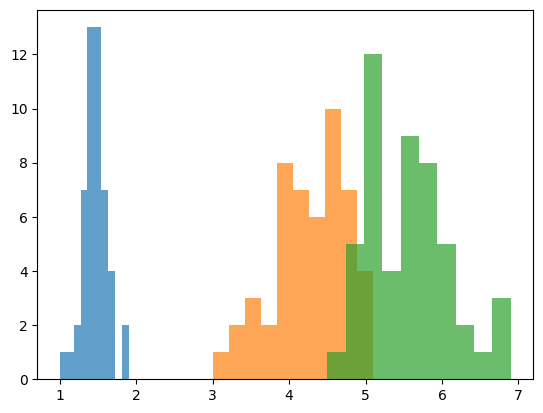

In [52]:
plt.hist(X[Y == 0,2],alpha=0.7)
plt.hist(X[Y == 1,2],alpha=0.7)
plt.hist(X[Y == 2,2],alpha=0.7)
plt.show()


Densidades kernels

/tmp/ipykernel_789/549207213.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[Y == 0,2],bins=10)
/tmp/ipykernel_789/549207213.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[Y == 1,2],bins=10)
/tmp/ipykernel_789/549207213.py:3: UserWarning: 

`distplot` is a deprecated function and wi

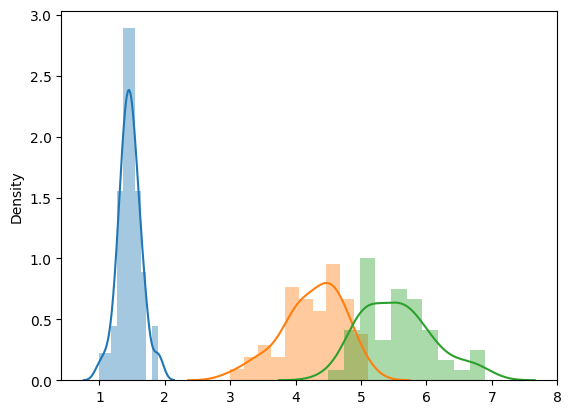

In [53]:
sns.distplot(X[Y == 0,2],bins=10)
sns.distplot(X[Y == 1,2],bins=10)
sns.distplot(X[Y == 2,2],bins=10)
plt.show()


KDE (Kernel density estimation) de una sola variable

/tmp/ipykernel_789/3447519622.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X[:,1],bins=10)


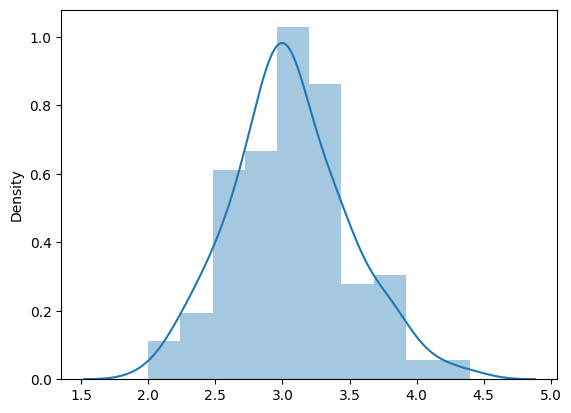

In [54]:
sns.distplot(X[:,1],bins=10)
plt.show()

Scatterplot

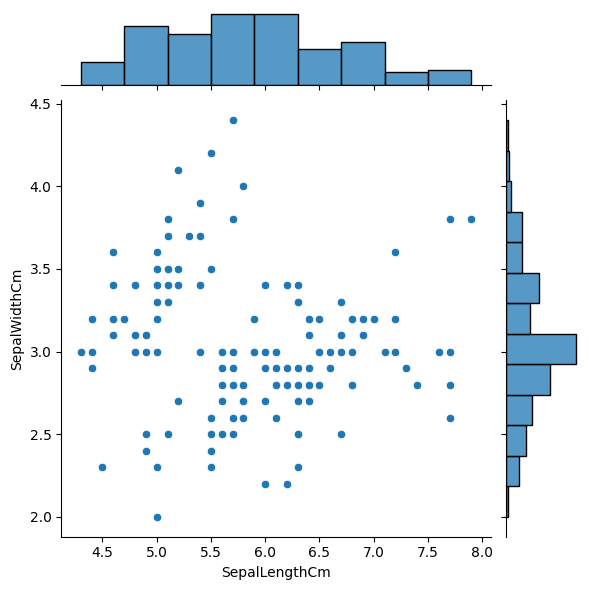

In [55]:
#Scatterplot donde salen también histogramas
fig=sns.jointplot(x='SepalLengthCm',y='SepalWidthCm',data=iris)

In [56]:
#Scatterplot en 3d y con movimiento
iris = px.data.iris()
fig = px.scatter_3d(iris, x='sepal_length', y='sepal_width', z='petal_width',
              color='species')
fig.show()

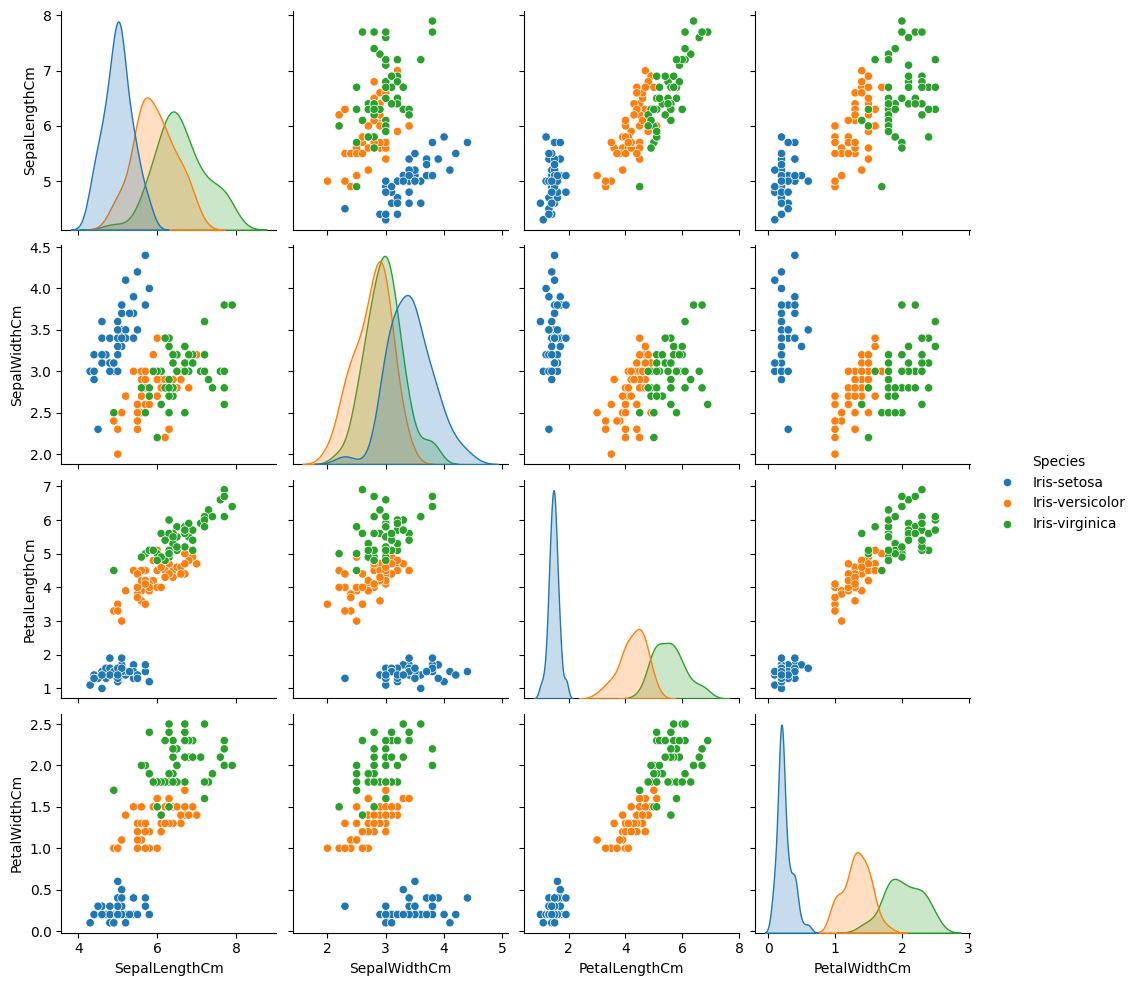

In [57]:
# Scatterplot matrix (kde en la diagonal)
sns.pairplot(iris_num,hue='Species')
plt.show()


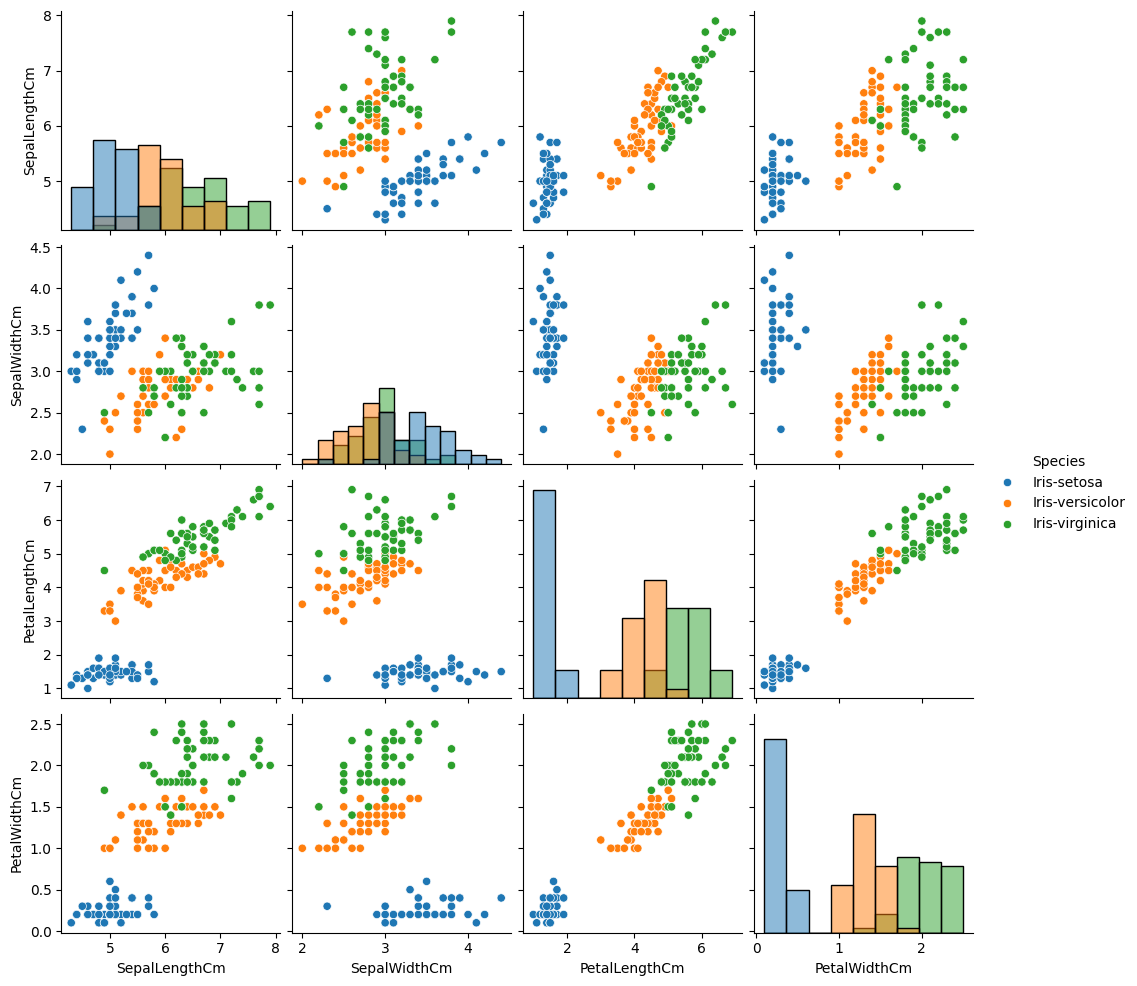

In [58]:
#Scatterplot matrix (histogramas en la diagonal)
sns.pairplot(iris_num,hue='Species', diag_kind='hist')
plt.show()

In [59]:
# Otra forma de cargar los datos IRIS (con seaborn - sns)
iris = sns.load_dataset("iris")
print(iris.head()) # no tiene variable Id, las demas vbles se llaman diferentes y las categorias tambien


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


/tmp/ipykernel_789/3570443235.py:4: UserWarning:



`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipykernel_789/3570443235.py:4: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipykernel_789/3570443235.py:6: UserWarning:



`shade_lowest` has been replaced by `thresh`; setting `thresh=0.05.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipykernel_789/3570443235.py:6: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




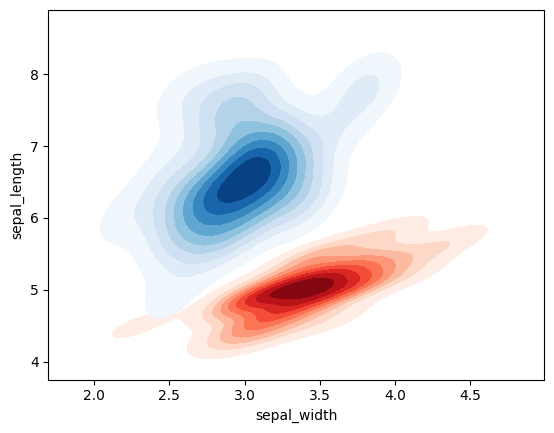

In [62]:
# Densidad kernel bidimensional
setosa = iris.loc[iris.species == "setosa"]
virginica = iris.loc[iris.species == "virginica"]
ax = sns.kdeplot(x=setosa.sepal_width, y=setosa.sepal_length,
                 cmap="Reds", shade=True, shade_lowest=False)
ax = sns.kdeplot(x=virginica.sepal_width, y=virginica.sepal_length,
               cmap="Blues", shade=True, shade_lowest=False)

Matriz de Covarianza
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Matriz de Correlaciones
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


(4.5, -0.5)

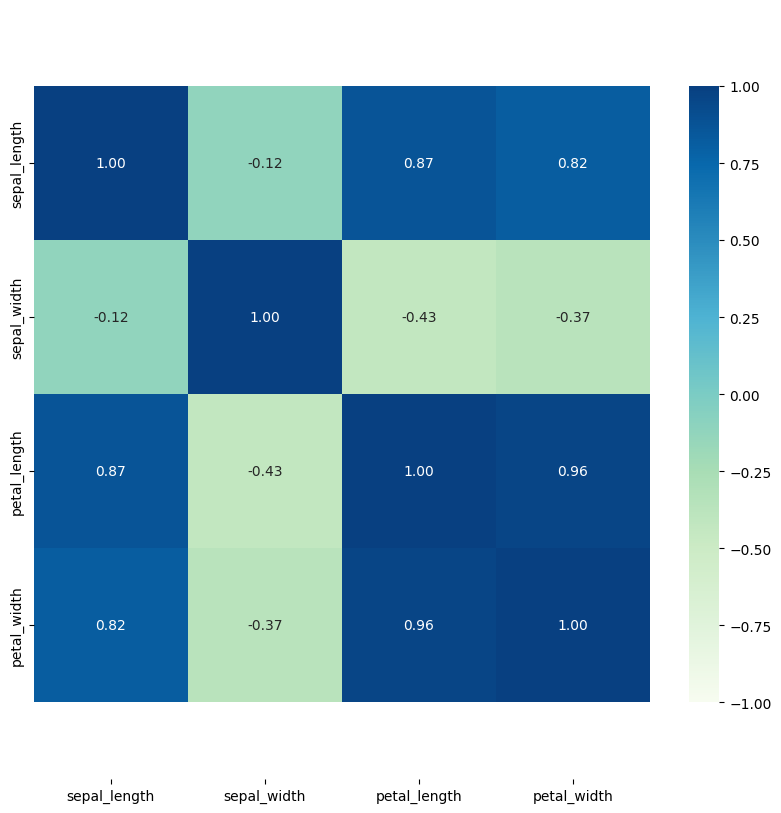

In [64]:
# Matriz de covarianza numerica
cov_matrix = iris.drop('species', axis=1).cov()

# Matriz de correlaciones numerica
correlation_matrix = iris.drop('species', axis=1).corr()
print('Matriz de Covarianza')
print(cov_matrix)
print('Matriz de Correlaciones')
print(correlation_matrix)

# Matriz de correlaciones gráfica
plt.figure(figsize=(10,10))
ax=sns.heatmap(correlation_matrix, vmax=1, vmin=-1,cbar_kws={"shrink": .8},square=True, annot=True,fmt='.2f', cmap ='GnBu',center=0)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

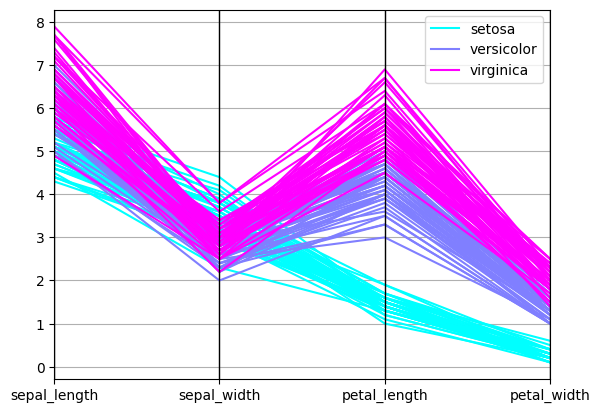

In [65]:
#Coordenadas paralelas
from pandas.plotting import parallel_coordinates
parallel_coordinates(iris, "species",colormap='cool')
plt.show()

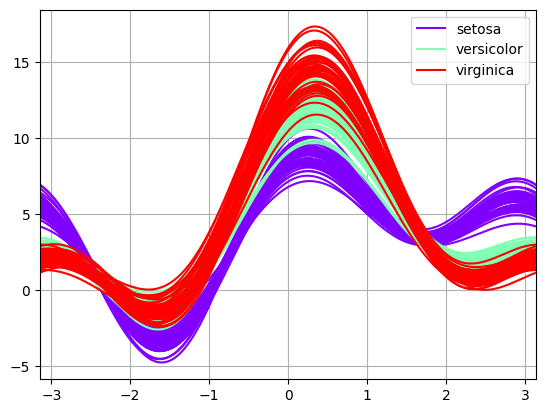

In [66]:
#Curvas de Andrews

andrews_curves(iris,"species",colormap='rainbow')
plt.show()


   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


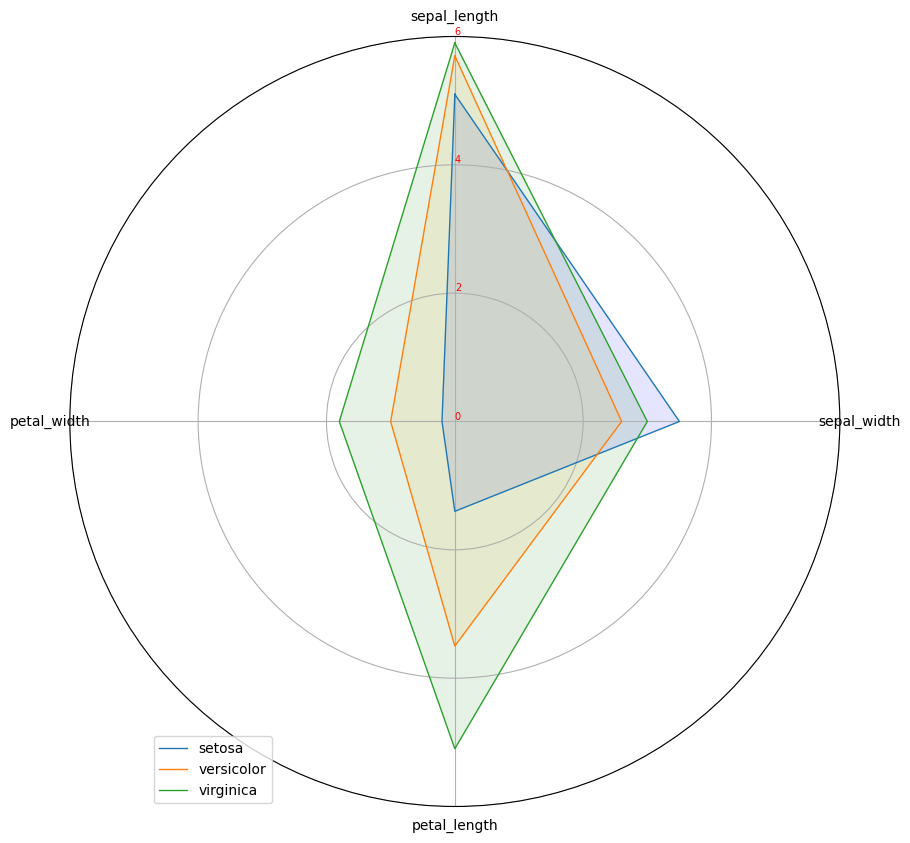

In [67]:
#Grafico Radial
new_iris=iris.drop('species',axis=1)
print(new_iris.head()) # le quitamos la variable species
categories = list(iris)[:4]
N = len(categories)
angles = [ n / float(N)*2*pi for n in range(N)]
angles = angles + angles[:1]
plt.figure(figsize = (10,10))
ax = plt.subplot(111,polar = True)
ax.set_theta_offset(pi/2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1],categories)
ax.set_rlabel_position(0)
plt.yticks([0,2,4,6],["0","2","4","6"],color= "red", size = 7)
plt.ylim(0,6)

values = new_iris.loc[0].values.flatten().tolist()
values = values + values[:1]
ax.plot(angles,values,linewidth = 1,linestyle="solid",label='setosa' )
ax.fill(angles,values,"b",alpha=0.1)


values = new_iris.loc[79].values.flatten().tolist()
values = values + values[:1]
ax.plot(angles,values,linewidth = 1,linestyle="solid",label='versicolor' )
ax.fill(angles,values,"orange",alpha=0.1)


values = new_iris.loc[149].values.flatten().tolist()
values = values + values[:1]
ax.plot(angles,values,linewidth = 1,linestyle="solid",label='virginica' )
ax.fill(angles,values,"green",alpha=0.1)

plt.legend(loc = "upper left",bbox_to_anchor = (0.1,0.1))
plt.show()